# Health insurance risk-based pricing: exploratory analysis & GLM fit

This notebook walks through the same actuarial pricing model used in the interactive dashboard
(`docs/index.html`), in full: data exploration, a Gamma GLM (log link) severity model, and
out-of-the-box validation (lift chart, coefficient significance).

Dataset: 1,338 US health insurance policies (age, sex, BMI, dependents, smoker status, region, annual charges).

## 1. Load and inspect the data

In [1]:
import pandas as pd

df = pd.read_csv("../data/insurance.csv")
df.head()

   age     sex     bmi  children smoker     region      charges  smoker_yes  sex_male
0   19  female  27.900         0    yes  southwest  16884.92400           1         0
1   18    male  33.770         1     no  southeast   1725.55230           0         1
2   28    male  33.000         3     no  southeast   4449.46200           0         1
3   33    male  22.705         0     no  northwest  21984.47061           0         1
4   32    male  28.880         0     no  northwest   3866.85520           0         1

In [1]:
df[["age","bmi","children","charges"]].describe().round(2)

           age      bmi  children   charges
count  1338.00  1338.00   1338.00   1338.00
mean     39.21    30.66      1.09  13270.42
std      14.05     6.10      1.21  12110.01
min      18.00    15.96      0.00   1121.87
25%      27.00    26.30      0.00   4740.29
50%      39.00    30.40      1.00   9382.03
75%      51.00    34.69      2.00  16639.91
max      64.00    53.13      5.00  63770.43

## 2. Why a Gamma distribution

Annual claims cost is strictly positive and heavily right-skewed: most people cost relatively little,
a small number cost a great deal. That shape is the textbook case for a Gamma GLM rather than ordinary
least squares, which assumes symmetric, potentially-negative errors.

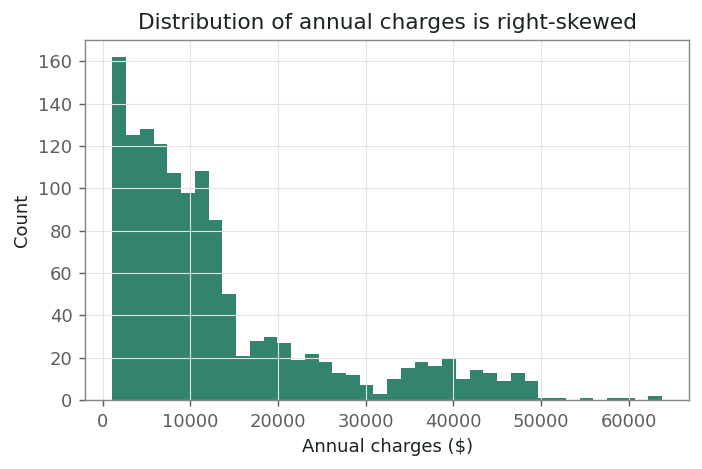

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,3.6))
ax.hist(df["charges"], bins=40, color="#0F6E56", alpha=0.85)
ax.set_xlabel("Annual charges ($)"); ax.set_ylabel("Count")
ax.set_title("Distribution of annual charges is right-skewed")
plt.show()

## 3. The single biggest driver: smoking

smoker
no     8434.27
yes    32050.23
Name: charges, dtype: float64
Ratio: 3.80x

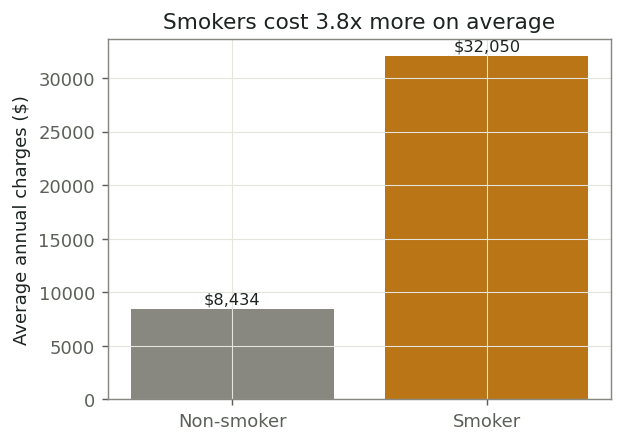

In [1]:
smoker_avg = df.groupby("smoker")["charges"].mean()
print(smoker_avg)
print(f"Ratio: {smoker_avg['yes']/smoker_avg['no']:.2f}x")

## 4. Age and smoking status together

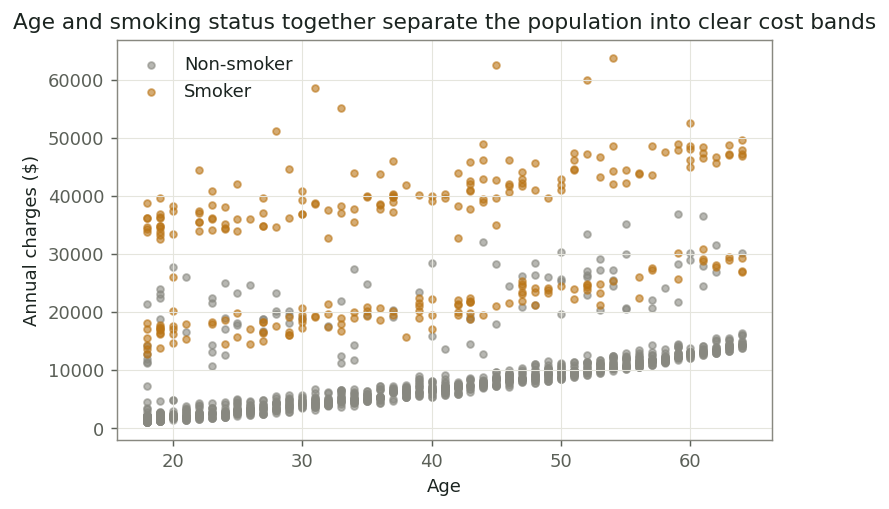

In [1]:
fig, ax = plt.subplots(figsize=(6.5,4))
for smk, color, label in [("no","#888880","Non-smoker"), ("yes","#BA7517","Smoker")]:
    sub = df[df.smoker == smk]
    ax.scatter(sub["age"], sub["charges"], s=14, alpha=0.6, color=color, label=label)
ax.set_xlabel("Age"); ax.set_ylabel("Annual charges ($)")
ax.legend(frameon=False)
plt.show()

## 5. The model: Gamma GLM with a log link

The log link makes every rating factor act *multiplicatively* on the baseline cost, which mirrors how
a real rate manual is built: a base rate multiplied by a relativity per factor. This is the same
formula powering the live calculator in the dashboard.

In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = "charges ~ age + bmi + children + smoker_yes + sex_male + C(region, Treatment(reference='northeast'))"
model = smf.glm(formula=formula, data=df, family=sm.families.Gamma(link=sm.families.links.Log()))
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1338
Model:                            GLM   Df Residuals:                     1329
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                         0.46695
Method:                          IRLS   Log-Likelihood:                -13307.
Date:                Wed, 24 Jun 2026   Deviance:                       337.73
Time:                        14:52:19   Pearson chi2:                     621.
No. Iterations:                    18   Pseudo R-squ. (CS):             0.6833
Covariance Type:            nonrobust                                         
                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

## 6. Validation: does the model actually separate risk well?

The standard actuarial check is a **lift chart**: rank policies by predicted cost, bucket into deciles,
and compare the average actual cost in each bucket to the average predicted cost. A good pricing model
tracks closely and monotonically increases left to right.

MAE: $4,389  RMSE: $7,771  Pseudo R-squared: 0.588

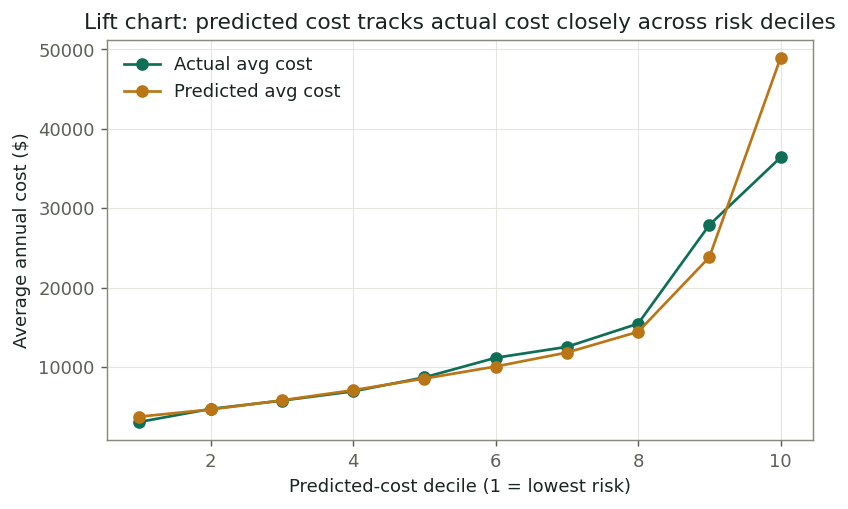

In [1]:
df["pred"] = result.predict(df)
df["decile"] = pd.qcut(df["pred"], 10, labels=False) + 1
lift = df.groupby("decile").agg(actual_mean=("charges","mean"), predicted_mean=("pred","mean")).reset_index()

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(lift["decile"], lift["actual_mean"], marker="o", color="#0F6E56", label="Actual avg cost")
ax.plot(lift["decile"], lift["predicted_mean"], marker="o", color="#BA7517", label="Predicted avg cost")
ax.set_xlabel("Predicted-cost decile"); ax.set_ylabel("Average annual cost ($)")
ax.legend(frameon=False)
plt.show()

print(f"MAE: ${mae:,.0f}  RMSE: ${rmse:,.0f}  Pseudo R-squared: {r2:.3f}")

## 7. Limitations

- This is a single cross-sectional snapshot (1,338 people, one point in time), not multi-year claims
  experience, so there's no out-of-sample holdout test here, the fit stats above are in-sample.
- The dataset has no claim-level detail, so this is a single severity-style cost model rather than a
  true frequency x severity split.
- Sex is statistically insignificant in this fit (p = 0.128). That's consistent with why several
  regulators (EU Gender Directive, US ACA individual/small-group market) exclude sex as a rating factor
  outright, this model would likely drop it even where legally permitted.

See `README.md` for the full project writeup and `docs/index.html` for the interactive version of this
same model.